In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

Matplotlib is building the font cache; this may take a moment.


In [14]:
import pandas as pd

df = pd.read_csv("../../data/Apple.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2026-02-27,272.81,272.81,262.89,264.18,264.18,"72,366,500"
2026-02-26,274.95,276.11,270.80,272.95,272.95,"32,345,100"
2026-02-25,271.78,274.94,271.05,274.23,274.23,"33,714,300"
2026-02-24,267.86,274.89,267.71,272.14,272.14,"47,014,600"
2026-02-23,263.49,269.43,263.38,266.18,266.18,"37,308,200"


In [16]:
series = df['Close']

In [21]:
print(df.columns)

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


In [35]:
train = series[series.index < '2024-01-01']
test = series[series.index >= '2024-01-01']

In [36]:
print(train.head())
print(test.head())

print("Train size:", len(train))
print("Test size:", len(test))

Date
2023-12-29    192.53
2023-12-28    193.58
2023-12-27    193.15
2023-12-26    193.05
2023-12-22    193.60
Name: Close, dtype: float64
Date
2026-02-27    264.18
2026-02-26    272.95
2026-02-25    274.23
2026-02-24    272.14
2026-02-23    266.18
Name: Close, dtype: float64
Train size: 2264
Test size: 541


In [37]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

predictions = model_fit.forecast(steps=len(test))

/Users/pihupawar/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/pihupawar/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/pihupawar/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/pihupawar/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecas

In [59]:
import pandas as pd

# Load CSV
df = pd.read_csv("../../data/Apple.csv")

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set Date as index
df.set_index('Date', inplace=True)

# Sort by date
df = df.sort_index()

# Select Close price
series = df['Close']

# Train / Test split
train = series[series.index < '2024-01-01']
test = series[series.index >= '2024-01-01']

print(train.head())
print(test.head())

Date
2015-01-02    27.33
2015-01-05    26.56
2015-01-06    26.57
2015-01-07    26.94
2015-01-08    27.97
Name: Close, dtype: float64
Date
2024-01-02    185.64
2024-01-03    184.25
2024-01-04    181.91
2024-01-05    181.18
2024-01-08    185.56
Name: Close, dtype: float64


In [61]:
model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2264
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -4568.035
Date:                Fri, 06 Mar 2026   AIC                           9148.071
Time:                        21:40:11   BIC                           9182.417
Sample:                             0   HQIC                          9160.603
                               - 2264                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0374      0.013     -2.913      0.004      -0.063      -0.012
ar.L2         -0.0240      0.013     -1.828      0.068      -0.050       0.002
ar.L3         -0.0130      0.014     -0.911      0.3

/Users/pihupawar/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/pihupawar/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/pihupawar/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/pihupawar/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/pihupa

In [62]:
predictions = model_fit.forecast(steps=len(test))

/Users/pihupawar/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/pihupawar/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [63]:
mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 35.24891285483401
RMSE: 42.66330375683935


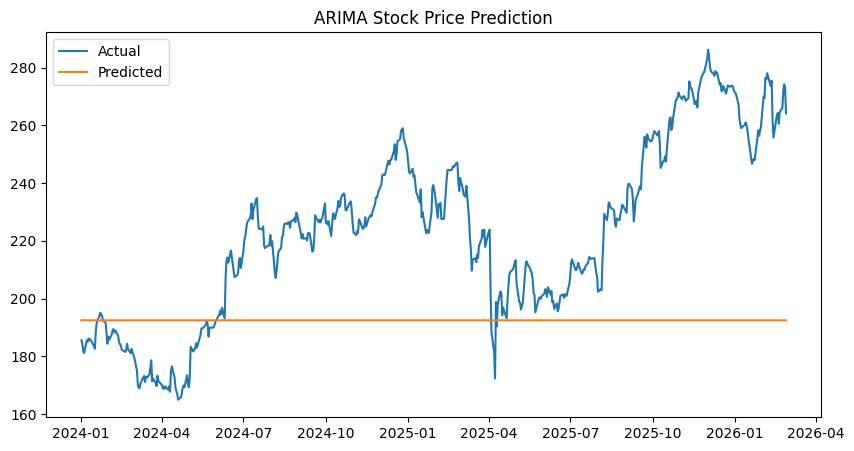

In [64]:
plt.figure(figsize=(10,5))

plt.plot(test.index, test, label="Actual")
plt.plot(test.index, predictions, label="Predicted")

plt.title("ARIMA Stock Price Prediction")
plt.legend()
plt.show()

In [65]:
future = model_fit.forecast(steps=7)

print("Next 7 Day Predictions")
print(future)

Next 7 Day Predictions
2264    192.517709
2265    192.516152
2266    192.532575
2267    192.552254
2268    192.510550
2269    192.510956
2270    192.511571
Name: predicted_mean, dtype: float64


/Users/pihupawar/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/pihupawar/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
